# IDS 705 — Group 10: Vulnerability of Medical AI
## Notebook 1: Full Attack Study
### PneumoniaMNIST+ · ResNet-18 (224×224)

**9 attack types · Single + Combined · Comprehensive Metrics**

| Part | Description |
|------|-------------|
| 1 | Visual preview of all attacks |
| 2 | Single attack evaluation (9 types × 5 levels) |
| 3 | Single attack ranking table |
| 4 | Combined 2-type attacks (33 valid pairs × 5 levels) |
| 5 | Combined 3-type attacks |
| 6 | Combined 4-type attacks |
| 7 | Combined 5-type attacks |
| 8 | Combined 6–9 type attacks |
| 9 | Master summary — ranking, clinical impact |

| What | Zenodo | File |
|------|--------|------|
| Dataset | [10519652](https://zenodo.org/records/10519652) | `pneumoniamnist_224.npz` |
| Weights | [7782114](https://zenodo.org/records/7782114) | `resnet18_224_1.pth` |

## 0. Install & import

In [1]:
!pip install medmnist scikit-learn --quiet

import os, zipfile, io, itertools
import requests
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageFilter
from itertools import combinations
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as tv_models

import medmnist
from medmnist import INFO, Evaluator, PneumoniaMNIST

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'medmnist : {medmnist.__version__}')
print(f'torch    : {torch.__version__}')
print(f'Device   : {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.2 MB/s eta 0:00:00
medmnist : 3.0.2
torch    : 2.10.0+cu128
Device   : cuda


## 1. Constants

In [2]:
DATA_FLAG    = 'pneumoniamnist'
SIZE         = 224
BATCH_SIZE   = 128
DATA_ROOT    = os.path.expanduser('~/.medmnist')
WEIGHTS_DIR  = './weights'
WEIGHTS_FILE = os.path.join(WEIGHTS_DIR, 'resnet18_224_1.pth')

info      = INFO[DATA_FLAG]
n_classes = len(info['label'])  # 2
MEAN      = [0.5, 0.5, 0.5]
STD       = [0.5, 0.5, 0.5]

# Clinical danger threshold — recall below this is dangerous
RECALL_DANGER_THRESHOLD = 0.90
# Robustness verdict thresholds (accuracy drop)
ROBUST_THRESHOLD     = 0.02
CONCERNING_THRESHOLD = 0.05

print(f'Task    : {info["task"]}')
print(f'Classes : {n_classes} → {info["label"]}')

Task    : binary-class
Classes : 2 → {'0': 'normal', '1': 'pneumonia'}


## 2. Download dataset

In [3]:
os.makedirs(DATA_ROOT, exist_ok=True)
NPZ_FILE = os.path.join(DATA_ROOT, 'pneumoniamnist_224.npz')

if not os.path.exists(NPZ_FILE):
    print('Downloading dataset...')
    _ = PneumoniaMNIST(split='test', download=True, size=SIZE)
    print('Done.')
else:
    print(f'Dataset already present: {NPZ_FILE}')

100%|██████████| 214M/214M [00:13<00:00, 15.9MB/s]


Done.


## 3. Download weights

In [4]:
os.makedirs(WEIGHTS_DIR, exist_ok=True)
ZIP_URL  = 'https://zenodo.org/records/7782114/files/weights_pneumoniamnist.zip?download=1'
ZIP_PATH = 'weights_pneumoniamnist.zip'

if not os.path.exists(WEIGHTS_FILE):
    print('Downloading weights...')
    response = requests.get(ZIP_URL, stream=True)
    response.raise_for_status()
    with open(ZIP_PATH, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        for member in zf.namelist():
            if member.endswith('.pth'):
                fname = os.path.basename(member)
                with zf.open(member) as src, open(os.path.join(WEIGHTS_DIR, fname), 'wb') as dst:
                    dst.write(src.read())
    print('Done.')
else:
    print(f'Weights already present: {WEIGHTS_FILE}')

Done.


## 4. Load model

In [5]:
model = tv_models.resnet18(weights=None, num_classes=n_classes)
ckpt  = torch.load(WEIGHTS_FILE, map_location=device)
state_dict = ckpt['net'] if (isinstance(ckpt, dict) and 'net' in ckpt) else ckpt
model.load_state_dict(state_dict, strict=True)
model.to(device)
model.eval()
print(f'Model loaded — {sum(p.numel() for p in model.parameters()):,} parameters ✓')

Model loaded — 11,177,538 parameters ✓


## 5. Attack definitions

**9 attack types** (brightness/contrast/gamma split by direction):

| # | Attack | Direction | L1 → L5 |
|---|--------|-----------|----------|
| 1 | Gaussian Blur | — | k=3→21, σ=0.5→5.0 |
| 2 | Downsampling | — | scale=0.5→0.1 |
| 3 | JPEG | — | quality=75→5 |
| 4 | Brightness Dark | darker | δ=-0.1→-0.5 |
| 5 | Brightness Bright | brighter | δ=+0.1→+0.5 |
| 6 | Contrast Low | reducing | α=0.8→0.2 |
| 7 | Contrast High | increasing | α=1.2→2.0 |
| 8 | Gamma Overexposed | γ<1, brightens darks | γ=0.9→0.1 |
| 9 | Gamma Underexposed | γ>1, darkens brights | γ=1.5→5.0 |

**Conflict rules** (cannot coexist in same combination):
- Brightness Dark + Brightness Bright
- Contrast Low + Contrast High
- Gamma Overexposed + Gamma Underexposed

In [6]:
# ── Severity level parameters ─────────────────────────────────────────────────
ATTACK_LEVELS = {
    'Gaussian Blur'       : [(3,0.5),(7,1.0),(11,2.0),(15,3.0),(21,5.0)],
    'Downsampling'        : [0.5, 0.4, 0.3, 0.2, 0.1],
    'JPEG'                : [75, 50, 30, 15, 5],
    'Brightness Dark'     : [-0.1,-0.2,-0.3,-0.4,-0.5],
    'Brightness Bright'   : [0.1, 0.2, 0.3, 0.4, 0.5],
    'Contrast Low'        : [0.8, 0.6, 0.4, 0.3, 0.2],
    'Contrast High'       : [1.2, 1.4, 1.6, 1.8, 2.0],
    'Gamma Overexposed'   : [0.9, 0.7, 0.5, 0.3, 0.1],
    'Gamma Underexposed'  : [1.5, 2.0, 3.0, 4.0, 5.0],
}
ATTACK_NAMES = list(ATTACK_LEVELS.keys())

# ── Conflict pairs ────────────────────────────────────────────────────────────
CONFLICTS = [
    {'Brightness Dark', 'Brightness Bright'},
    {'Contrast Low',    'Contrast High'},
    {'Gamma Overexposed', 'Gamma Underexposed'},
]

def is_valid_combo(attack_list):
    """Returns True if no conflicting pair exists in the combination."""
    attack_set = set(attack_list)
    for conflict in CONFLICTS:
        if conflict.issubset(attack_set):
            return False
    return True

# ── PIL helper: JPEG compress in memory ──────────────────────────────────────
def jpeg_compress_pil(img, quality):
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).copy()

# ── Tensor helper: Gaussian noise ────────────────────────────────────────────
def add_noise(t, sigma):
    return torch.clamp(t + torch.randn_like(t) * sigma, -1.0, 1.0)

# ── Tensor helper: Gamma correction ──────────────────────────────────────────
def apply_gamma(t, gamma):
    t_01 = (t + 1) / 2                          # [-1,1] → [0,1]
    t_gamma = torch.pow(t_01.clamp(min=1e-8), gamma)
    return (t_gamma * 2 - 1).clamp(-1, 1)       # [0,1] → [-1,1]

print(f'Attack types defined: {len(ATTACK_NAMES)}')
print(f'Conflict pairs: {len(CONFLICTS)}')

Attack types defined: 9
Conflict pairs: 3


## 6. Transform builder

In [7]:
def make_clean_transform():
    return transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('RGB')),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ])

def make_single_transform(attack_name, level_idx):
    """
    Builds a transform for a single attack at a given level index (0-4).
    PIL-space attacks: Blur, JPEG, Downsample (applied before ToTensor)
    Tensor-space attacks: Brightness, Contrast, Gamma (applied after Normalize)
    """
    param = ATTACK_LEVELS[attack_name][level_idx]
    pil_steps = [
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('RGB')),
    ]
    tensor_steps = []

    if attack_name == 'Gaussian Blur':
        ks, sig = param
        pil_steps.append(transforms.GaussianBlur(kernel_size=ks, sigma=sig))
    elif attack_name == 'Downsampling':
        small = max(1, int(SIZE * param))
        pil_steps.append(transforms.Resize((small, small), interpolation=Image.NEAREST))
        pil_steps.append(transforms.Resize((SIZE, SIZE),  interpolation=Image.NEAREST))
    elif attack_name == 'JPEG':
        pil_steps.append(transforms.Lambda(lambda img, q=param: jpeg_compress_pil(img, q)))
    elif attack_name in ('Brightness Dark', 'Brightness Bright'):
        tensor_steps.append(transforms.Lambda(lambda t, d=param: torch.clamp(t + d, -1.0, 1.0)))
    elif attack_name in ('Contrast Low', 'Contrast High'):
        tensor_steps.append(transforms.Lambda(lambda t, a=param: torch.clamp(t * a, -1.0, 1.0)))
    elif attack_name in ('Gamma Overexposed', 'Gamma Underexposed'):
        tensor_steps.append(transforms.Lambda(lambda t, g=param: apply_gamma(t, g)))

    return transforms.Compose(
        pil_steps +
        [transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)] +
        tensor_steps
    )

def make_combined_transform(attack_names, level_idx):
    """
    Builds a transform applying multiple attacks at the same level index.
    PIL attacks applied first, then tensor attacks after Normalize.
    """
    pil_steps = [
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('RGB')),
    ]
    tensor_steps = []

    for name in attack_names:
        param = ATTACK_LEVELS[name][level_idx]
        if name == 'Gaussian Blur':
            ks, sig = param
            pil_steps.append(transforms.GaussianBlur(kernel_size=ks, sigma=sig))
        elif name == 'Downsampling':
            small = max(1, int(SIZE * param))
            pil_steps.append(transforms.Resize((small, small), interpolation=Image.NEAREST))
            pil_steps.append(transforms.Resize((SIZE, SIZE),  interpolation=Image.NEAREST))
        elif name == 'JPEG':
            pil_steps.append(transforms.Lambda(lambda img, q=param: jpeg_compress_pil(img, q)))
        elif name in ('Brightness Dark', 'Brightness Bright'):
            tensor_steps.append(transforms.Lambda(lambda t, d=param: torch.clamp(t + d, -1.0, 1.0)))
        elif name in ('Contrast Low', 'Contrast High'):
            tensor_steps.append(transforms.Lambda(lambda t, a=param: torch.clamp(t * a, -1.0, 1.0)))
        elif name in ('Gamma Overexposed', 'Gamma Underexposed'):
            tensor_steps.append(transforms.Lambda(lambda t, g=param: apply_gamma(t, g)))

    return transforms.Compose(
        pil_steps +
        [transforms.ToTensor(), transforms.Normalize(mean=MEAN, std=STD)] +
        tensor_steps
    )

def make_loader(transform):
    ds = PneumoniaMNIST(
        split='test', transform=transform,
        download=False, root=DATA_ROOT, size=SIZE
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('Transform builder ready ✓')

Transform builder ready ✓


## 7. Inference and evaluation functions

In [8]:
def run_inference(model, loader, device):
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            scores = torch.softmax(logits, dim=1)
            all_scores.append(scores.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


def compute_metrics(y_score, y_true):
    """Returns metrics dict using medmnist.Evaluator for AUC/Acc + sklearn for P/R/F1."""
    evaluator = Evaluator(DATA_FLAG, 'test', size=SIZE)
    auc, acc  = evaluator.evaluate(y_score, save_folder=None, run=None)
    y_pred    = (y_score[:, 1] >= 0.5).astype(int)
    y_true_f  = y_true.flatten().astype(int)
    return {
        'accuracy' : float(acc),
        'auroc'    : float(auc),
        'precision': precision_score(y_true_f, y_pred, zero_division=0),
        'recall'   : recall_score(y_true_f, y_pred, zero_division=0),
        'f1'       : f1_score(y_true_f, y_pred, zero_division=0),
    }


def get_confusion_matrix(y_score, y_true):
    y_pred   = (y_score[:, 1] >= 0.5).astype(int)
    y_true_f = y_true.flatten().astype(int)
    cm = confusion_matrix(y_true_f, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}


def verdict(acc_drop):
    if acc_drop < ROBUST_THRESHOLD:
        return 'ROBUST'
    elif acc_drop < CONCERNING_THRESHOLD:
        return 'CONCERNING'
    else:
        return 'VULNERABLE'


print('Evaluation functions ready ✓')

Evaluation functions ready ✓


## 8. Clean baseline

In [9]:
print('Evaluating on clean test set...')
clean_loader = make_loader(make_clean_transform())
y_score_clean, y_true = run_inference(model, clean_loader, device)
baseline = compute_metrics(y_score_clean, y_true)
baseline_cm = get_confusion_matrix(y_score_clean, y_true)

print('\n=== Baseline (clean) ===')
for k, v in baseline.items():
    print(f'  {k:12s}: {v:.4f}')
print(f'\n  Confusion Matrix:')
print(f'  TN={baseline_cm["TN"]}  FP={baseline_cm["FP"]}')
print(f'  FN={baseline_cm["FN"]}  TP={baseline_cm["TP"]}')

Evaluating on clean test set...

=== Baseline (clean) ===
  accuracy    : 0.8942
  auroc       : 0.9553
  precision   : 0.8716
  recall      : 0.9744
  f1          : 0.9201

  Confusion Matrix:
  TN=178  FP=56
  FN=10  TP=380


---
# PART 1 — Visual Preview of All Attacks
Shows what each attack looks like at each severity level on a real chest X-ray.

/tmp/ipykernel_544/171592256.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(lbl) == 1:


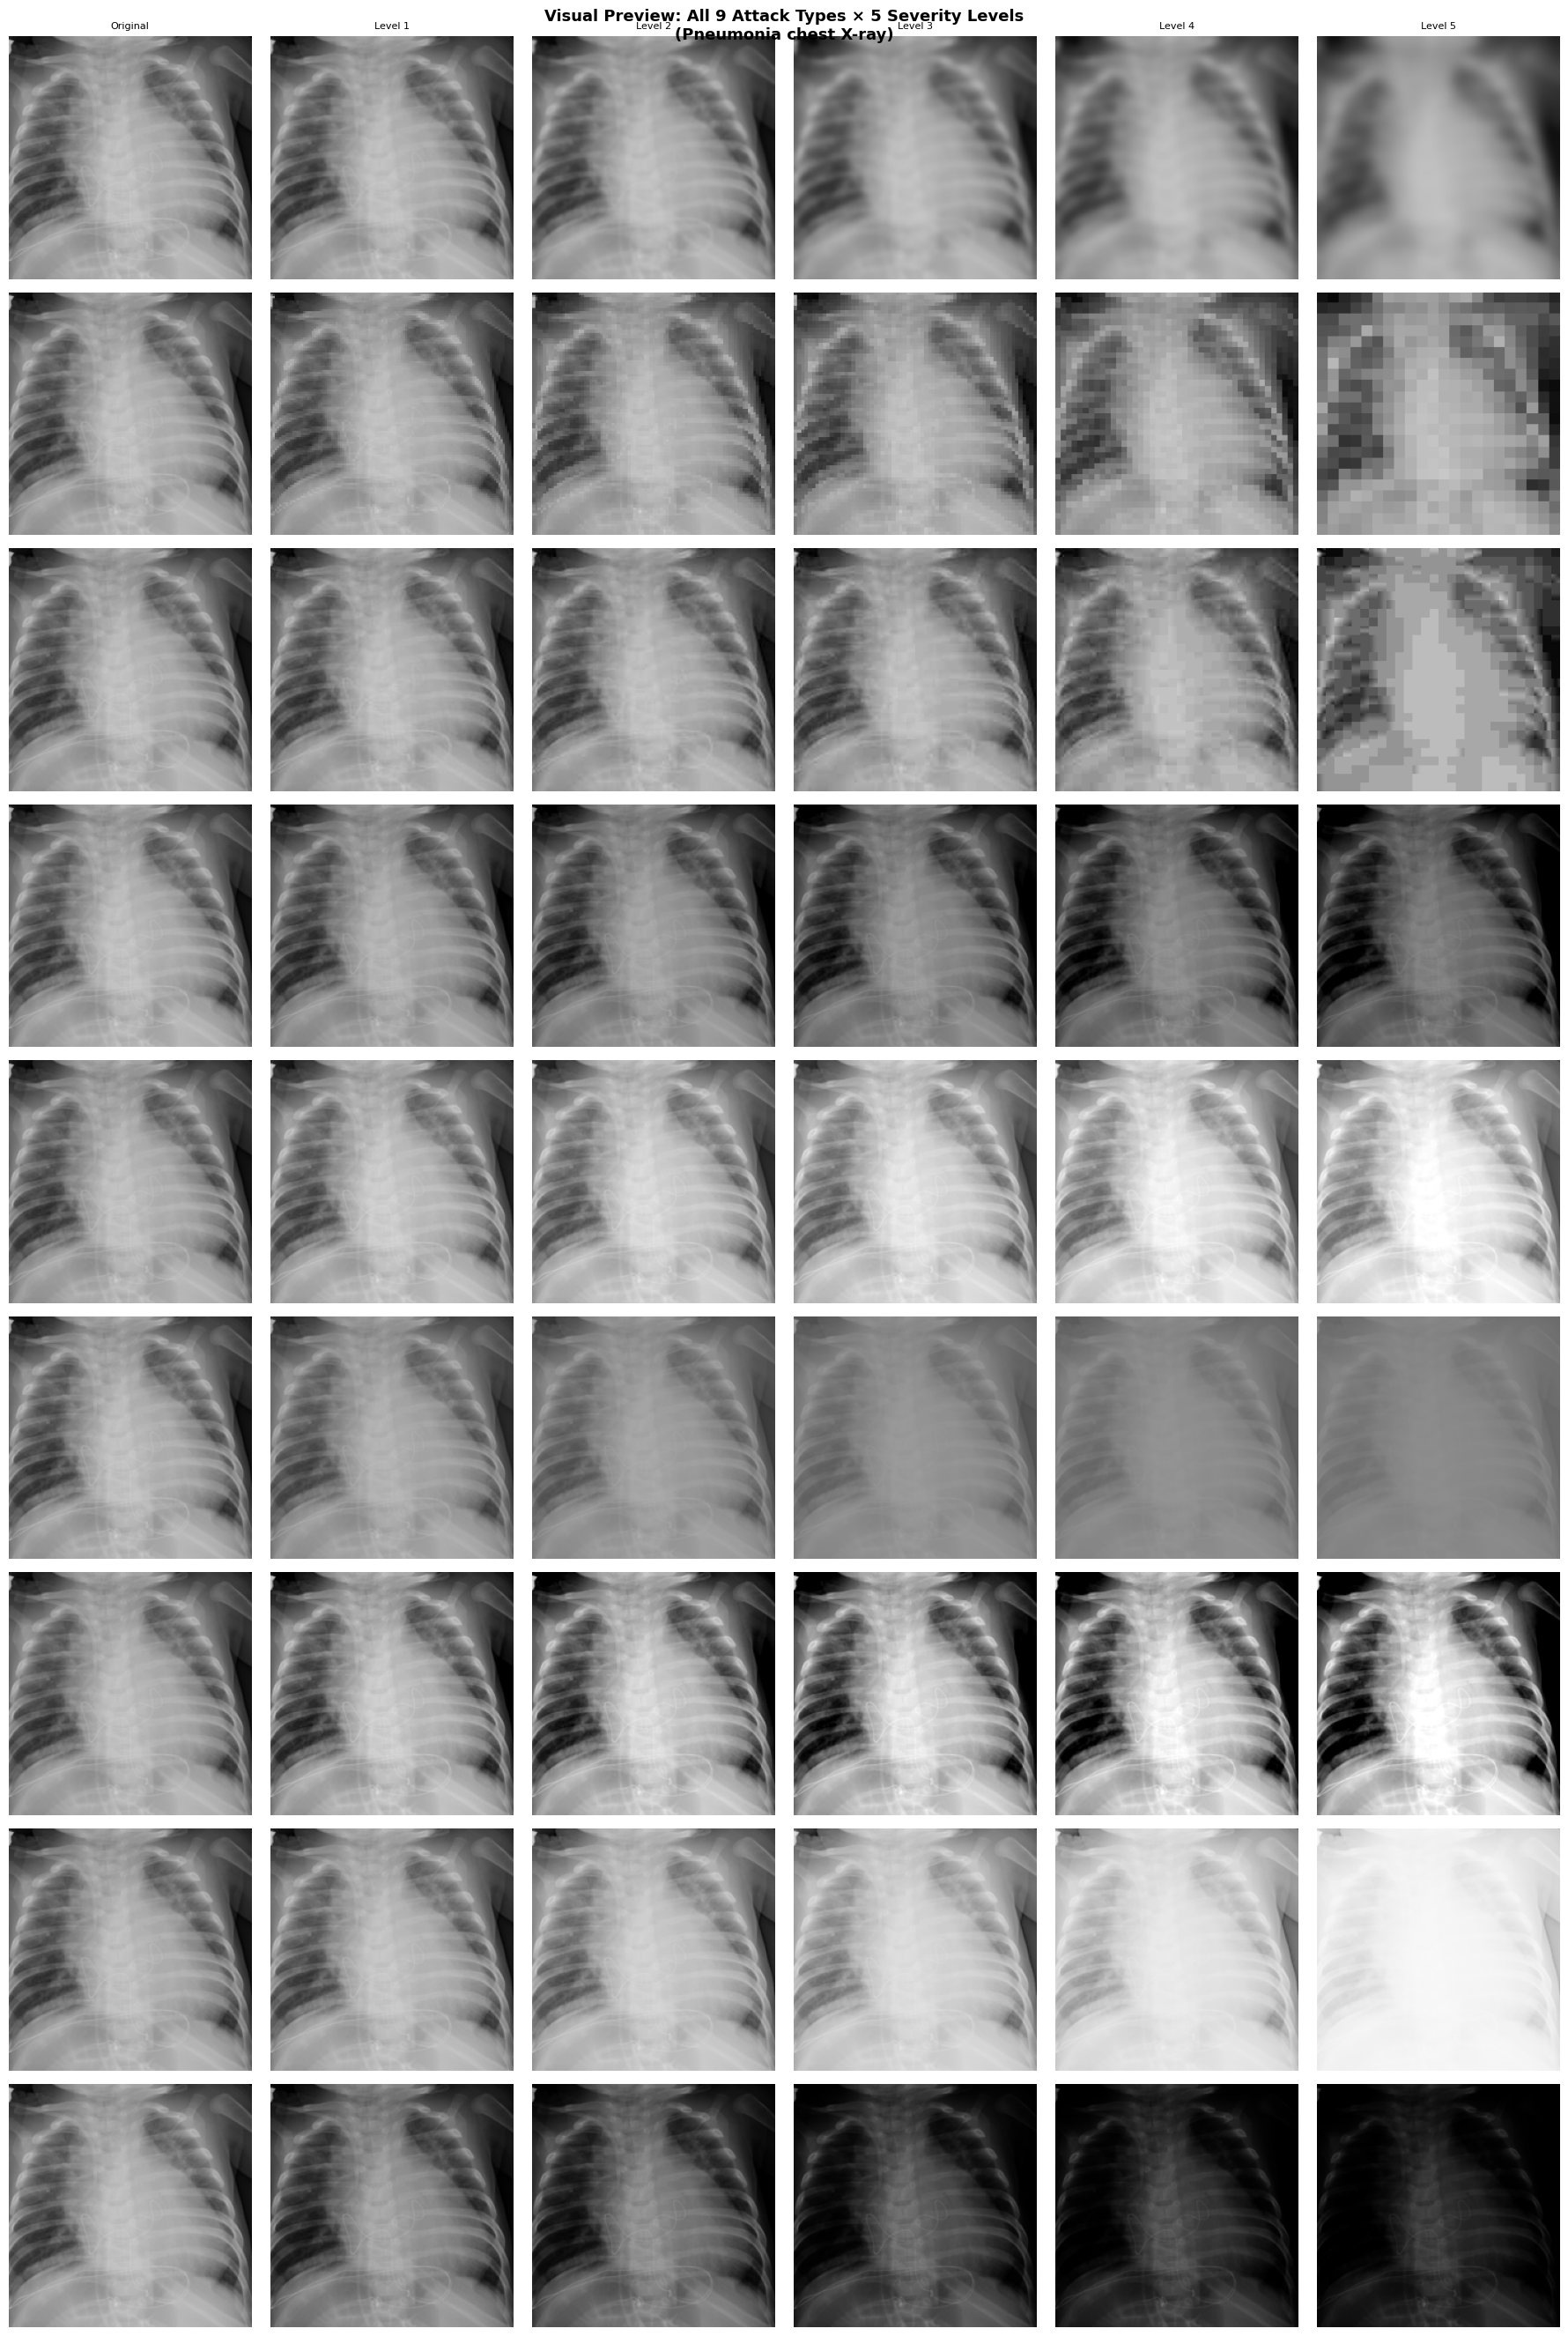

Part 1 complete ✓


In [10]:
# Load raw PIL images for display
raw_ds = PneumoniaMNIST(split='test', transform=None,
                        download=False, root=DATA_ROOT, size=SIZE)

# Find one Pneumonia sample for display
for i in range(len(raw_ds)):
    img_pil, lbl = raw_ds[i]
    if int(lbl) == 1:
        sample_img = img_pil.resize((SIZE, SIZE), Image.NEAREST).convert('RGB')
        break

def pil_preview(attack_name, level_idx):
    """Returns a PIL image with the attack applied for display purposes."""
    img = sample_img.copy()
    param = ATTACK_LEVELS[attack_name][level_idx]

    # PIL-space attacks
    if attack_name == 'Gaussian Blur':
        ks, sig = param
        img = transforms.GaussianBlur(kernel_size=ks, sigma=sig)(img)
    elif attack_name == 'Downsampling':
        small = max(1, int(SIZE * param))
        img = img.resize((small, small), Image.NEAREST).resize((SIZE, SIZE), Image.NEAREST)
    elif attack_name == 'JPEG':
        img = jpeg_compress_pil(img, param)
    else:
        # Tensor-space attacks — apply via tensor then convert back
        t = transforms.ToTensor()(img)
        t = transforms.Normalize(mean=MEAN, std=STD)(t)
        if attack_name in ('Brightness Dark', 'Brightness Bright'):
            t = torch.clamp(t + param, -1.0, 1.0)
        elif attack_name in ('Contrast Low', 'Contrast High'):
            t = torch.clamp(t * param, -1.0, 1.0)
        elif attack_name in ('Gamma Overexposed', 'Gamma Underexposed'):
            t = apply_gamma(t, param)
        # Denormalize back to [0,1] for display
        t = (t * 0.5 + 0.5).clamp(0, 1)
        img = transforms.ToPILImage()(t)
    return img

# Plot: 9 attacks (rows) × 6 columns (original + 5 levels)
fig, axes = plt.subplots(9, 6, figsize=(18, 27))
level_labels = ['Original', 'Level 1', 'Level 2', 'Level 3', 'Level 4', 'Level 5']

for row, attack_name in enumerate(ATTACK_NAMES):
    # Original
    axes[row, 0].imshow(sample_img)
    axes[row, 0].set_ylabel(attack_name, fontsize=8, rotation=90, labelpad=5)
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_title('Original', fontsize=8)

    # Each level
    for col in range(5):
        preview = pil_preview(attack_name, col)
        axes[row, col+1].imshow(preview)
        axes[row, col+1].axis('off')
        if row == 0:
            axes[row, col+1].set_title(f'Level {col+1}', fontsize=8)

fig.suptitle('Visual Preview: All 9 Attack Types × 5 Severity Levels\n(Pneumonia chest X-ray)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Part 1 complete ✓')

---
# PART 2 — Single Attack Evaluation
9 attacks × 5 levels = 45 experiments
Confusion matrix computed at Level 5 (worst case) for each attack.

In [11]:
single_results = {}   # {attack_name: {level: metrics}}
single_cm      = {}   # {attack_name: confusion_matrix at level 5}

total = len(ATTACK_NAMES) * 5
done  = 0

for attack_name in ATTACK_NAMES:
    print(f'\n--- {attack_name} ---')
    single_results[attack_name] = {}

    for level_idx in range(5):
        tfm    = make_single_transform(attack_name, level_idx)
        loader = make_loader(tfm)
        y_score, _ = run_inference(model, loader, device)
        m = compute_metrics(y_score, y_true)
        single_results[attack_name][level_idx + 1] = m
        done += 1
        print(f'  L{level_idx+1}: Acc={m["accuracy"]:.4f}  '
              f'F1={m["f1"]:.4f}  AUROC={m["auroc"]:.4f}  '
              f'Recall={m["recall"]:.4f}  '
              f'[{done}/{total}]')

        # Confusion matrix at level 5
        if level_idx == 4:
            single_cm[attack_name] = get_confusion_matrix(y_score, y_true)

print('\n✓ Part 2 complete')


--- Gaussian Blur ---
  L1: Acc=0.8942  F1=0.9203  AUROC=0.9555  Recall=0.9769  [1/45]
  L2: Acc=0.8926  F1=0.9192  AUROC=0.9547  Recall=0.9769  [2/45]
  L3: Acc=0.8958  F1=0.9218  AUROC=0.9533  Recall=0.9821  [3/45]
  L4: Acc=0.8894  F1=0.9178  AUROC=0.9533  Recall=0.9872  [4/45]
  L5: Acc=0.8606  F1=0.8992  AUROC=0.9488  Recall=0.9949  [5/45]

--- Downsampling ---
  L1: Acc=0.8926  F1=0.9192  AUROC=0.9555  Recall=0.9769  [6/45]
  L2: Acc=0.8926  F1=0.9194  AUROC=0.9548  Recall=0.9795  [7/45]
  L3: Acc=0.8942  F1=0.9205  AUROC=0.9553  Recall=0.9795  [8/45]
  L4: Acc=0.8942  F1=0.9203  AUROC=0.9560  Recall=0.9769  [9/45]
  L5: Acc=0.8574  F1=0.8973  AUROC=0.9529  Recall=0.9974  [10/45]

--- JPEG ---
  L1: Acc=0.8942  F1=0.9201  AUROC=0.9553  Recall=0.9744  [11/45]
  L2: Acc=0.8974  F1=0.9225  AUROC=0.9554  Recall=0.9769  [12/45]
  L3: Acc=0.8910  F1=0.9179  AUROC=0.9554  Recall=0.9744  [13/45]
  L4: Acc=0.8878  F1=0.9157  AUROC=0.9540  Recall=0.9744  [14/45]
  L5: Acc=0.8910  F1=0.918

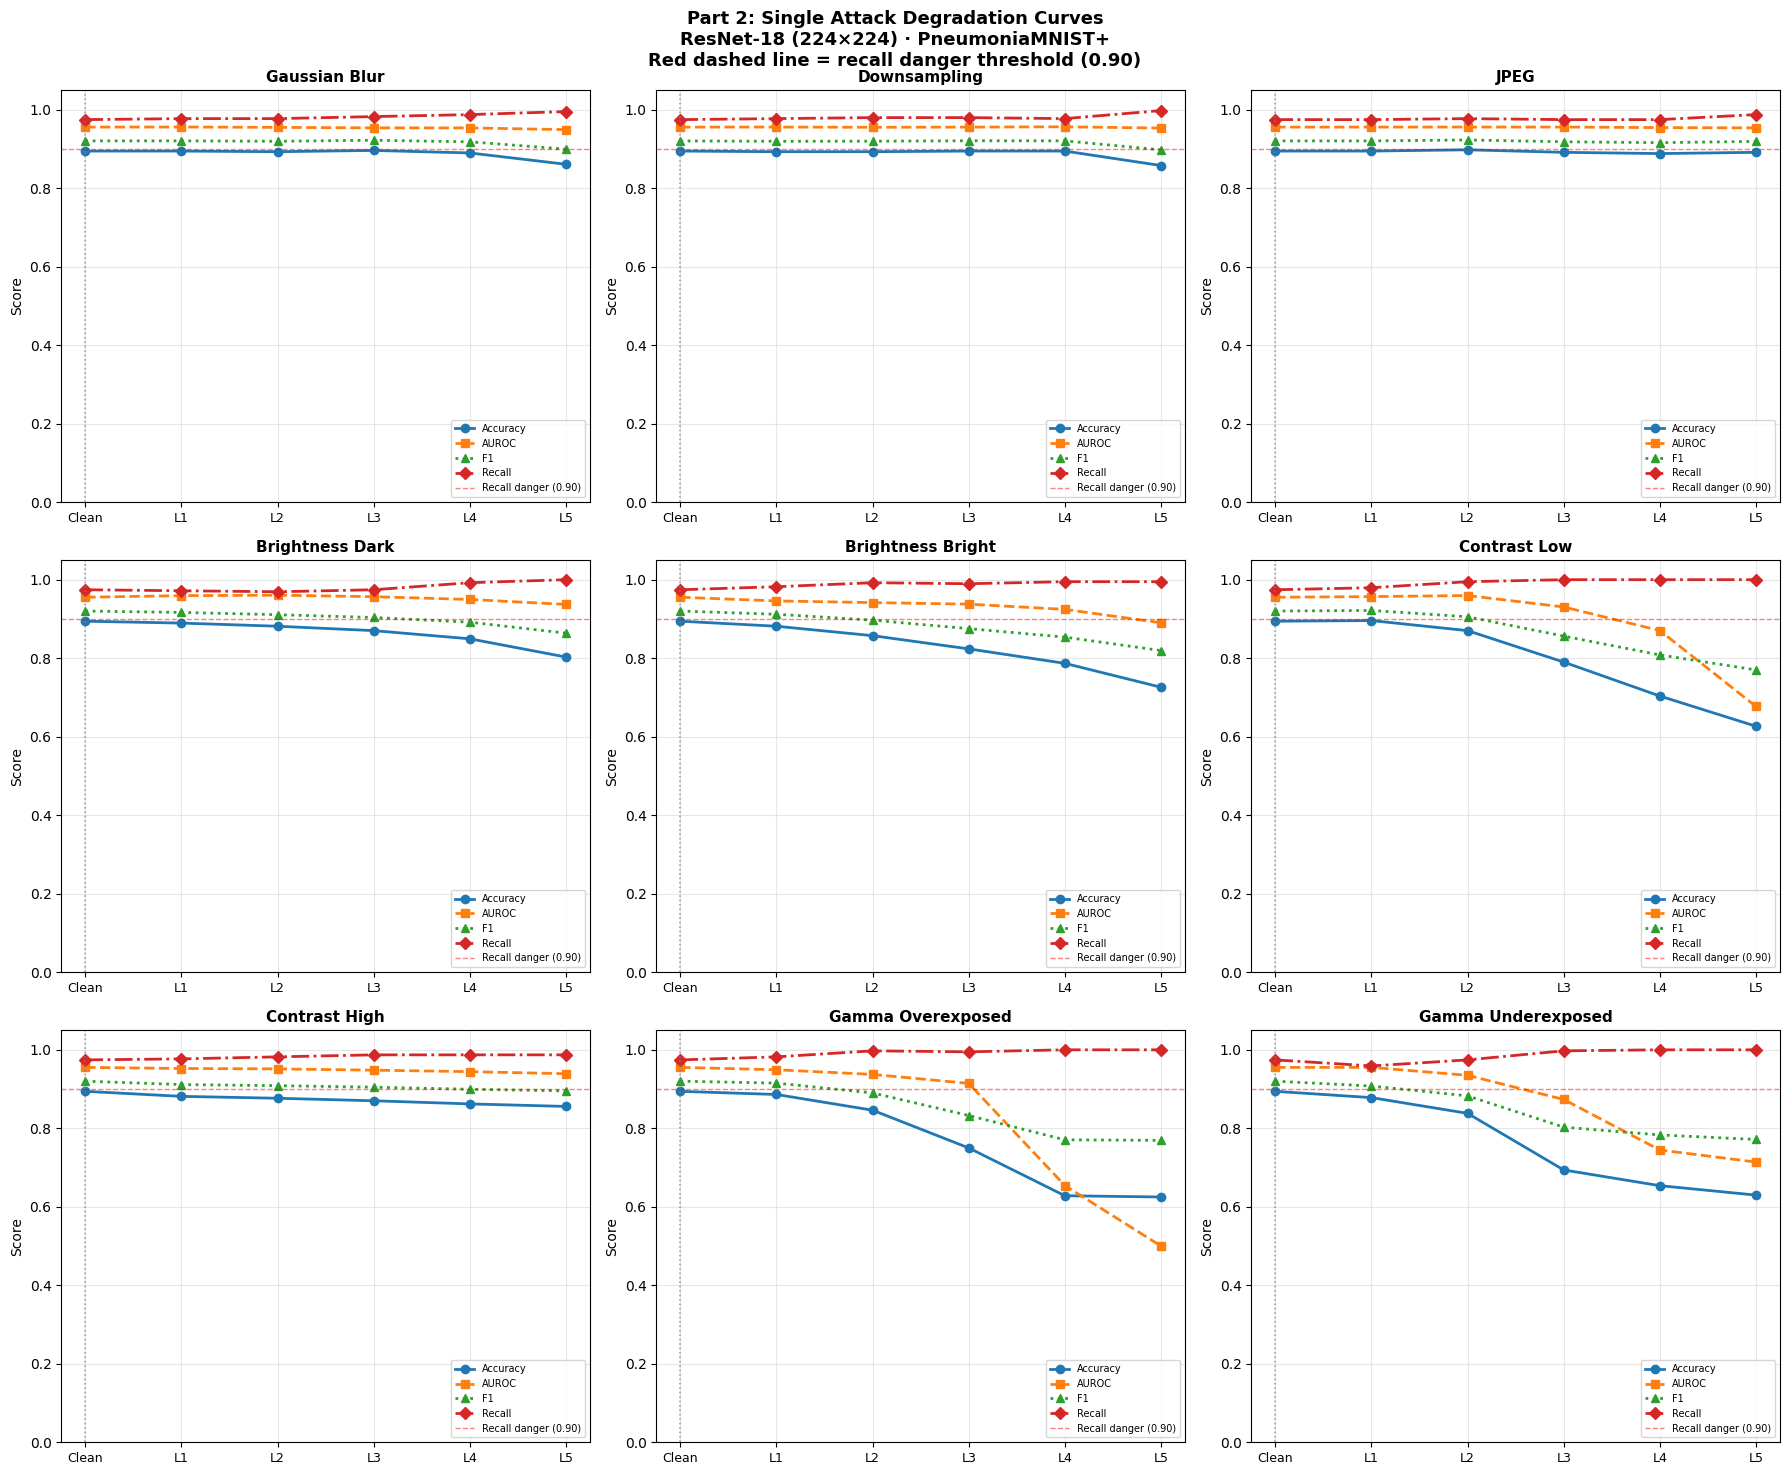

Degradation curves plotted ✓


In [12]:
# Line plots for all 9 single attacks (3×3 grid)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()
x_pos    = list(range(6))   # 0=clean, 1-5=levels
x_labels = ['Clean', 'L1', 'L2', 'L3', 'L4', 'L5']
styles   = [('o-','tab:blue'), ('s--','tab:orange'), ('^:','tab:green'), ('D-.','tab:red')]
metrics_to_plot = ['accuracy', 'auroc', 'f1', 'recall']

for ax, attack_name in zip(axes, ATTACK_NAMES):
    level_results = single_results[attack_name]
    series = {
        m: [baseline[m]] + [level_results[l][m] for l in range(1, 6)]
        for m in metrics_to_plot
    }
    for (style, color), (metric, values) in zip(styles, series.items()):
        ax.plot(x_pos, values, style, color=color,
                label=metric.upper() if metric == 'auroc' else metric.capitalize(),
                linewidth=2, markersize=6)

    ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
    ax.axhline(y=RECALL_DANGER_THRESHOLD, color='red', linestyle='--',
               linewidth=1, alpha=0.5, label='Recall danger (0.90)')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_title(attack_name, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Part 2: Single Attack Degradation Curves\nResNet-18 (224×224) · PneumoniaMNIST+\n'
             'Red dashed line = recall danger threshold (0.90)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Degradation curves plotted ✓')

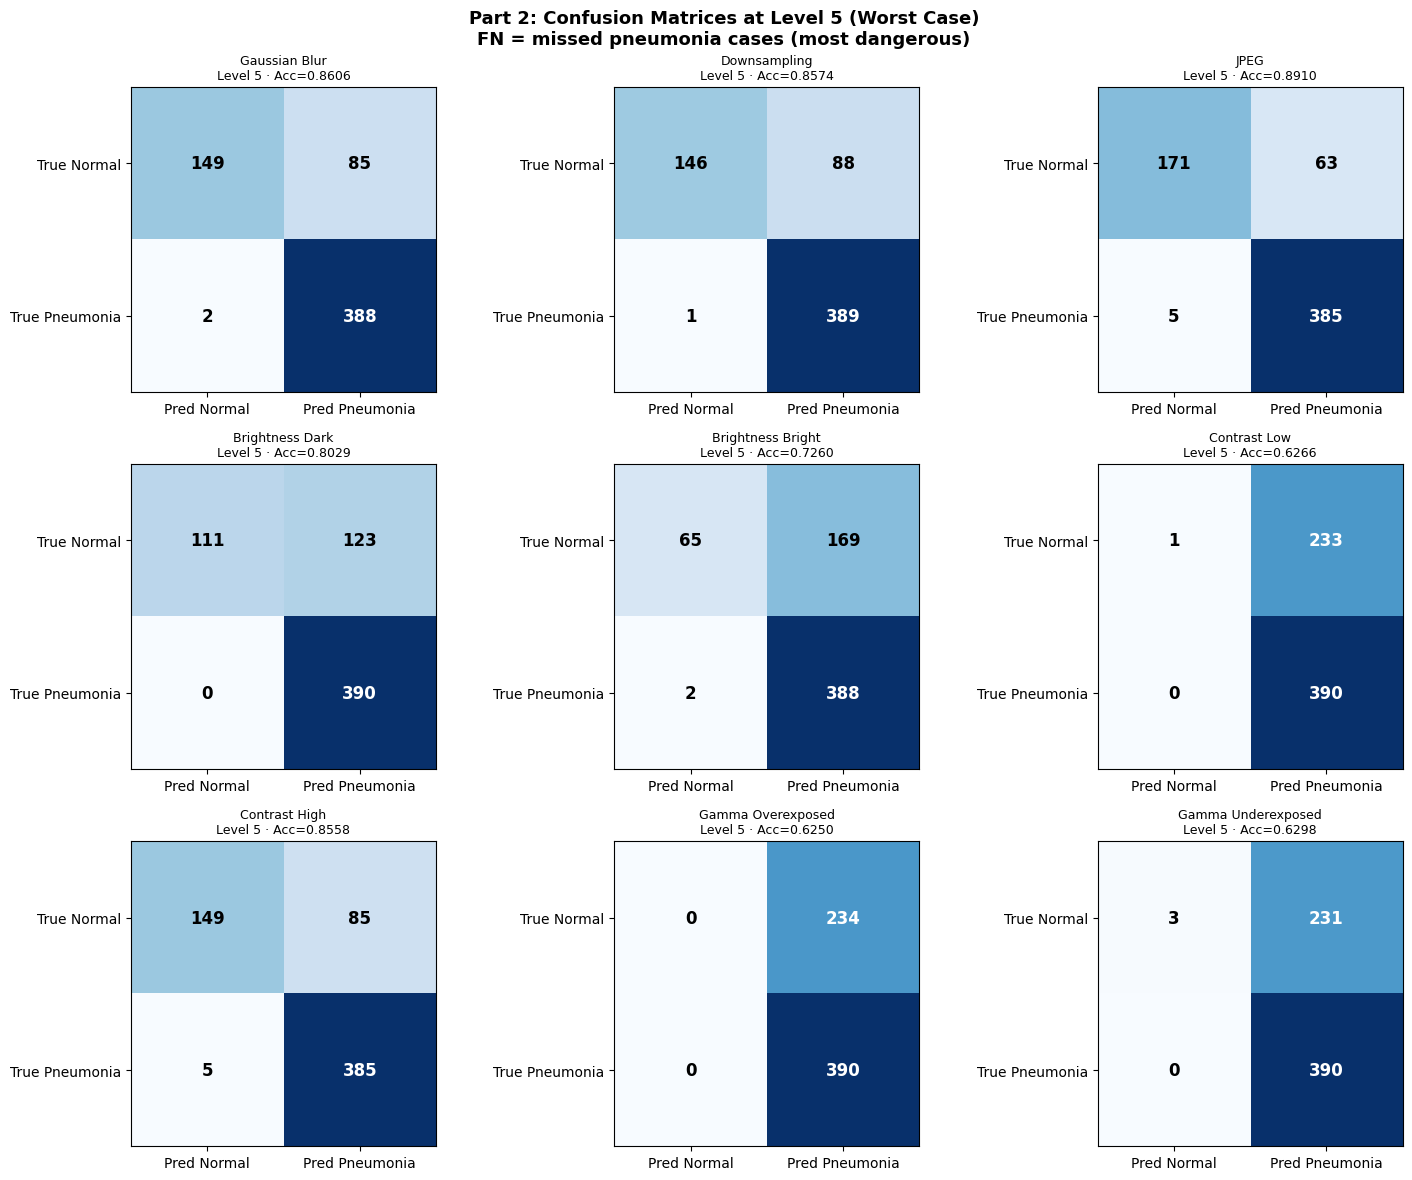

Confusion matrices plotted ✓


In [13]:
# Confusion matrices at Level 5 for all 9 attacks
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for ax, attack_name in zip(axes, ATTACK_NAMES):
    cm = single_cm[attack_name]
    cm_array = np.array([[cm['TN'], cm['FP']], [cm['FN'], cm['TP']]])

    im = ax.imshow(cm_array, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Normal', 'Pred Pneumonia'])
    ax.set_yticklabels(['True Normal', 'True Pneumonia'])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_array[i, j]),
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    color='white' if cm_array[i, j] > cm_array.max()/2 else 'black')

    acc_l5 = single_results[attack_name][5]['accuracy']
    ax.set_title(f'{attack_name}\nLevel 5 · Acc={acc_l5:.4f}', fontsize=9)

fig.suptitle('Part 2: Confusion Matrices at Level 5 (Worst Case)\n'
             'FN = missed pneumonia cases (most dangerous)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Confusion matrices plotted ✓')

In [14]:
# Full metrics table for all single attacks
rows = [{'attack': 'Clean (baseline)', 'level': '-', **baseline}]
for attack_name in ATTACK_NAMES:
    for level in range(1, 6):
        rows.append({
            'attack': attack_name,
            'level' : str(level),
            **single_results[attack_name][level]
        })

df_single = pd.DataFrame(rows).set_index(['attack', 'level'])
df_single = df_single[['accuracy','precision','recall','f1','auroc']].round(4)
df_single.to_csv('part2_single_results.csv')
print(df_single.to_string())
print('\nSaved: part2_single_results.csv')

                          accuracy  precision  recall      f1   auroc
attack             level                                             
Clean (baseline)   -        0.8942     0.8716  0.9744  0.9201  0.9553
Gaussian Blur      1        0.8942     0.8699  0.9769  0.9203  0.9555
                   2        0.8926     0.8679  0.9769  0.9192  0.9547
                   3        0.8958     0.8685  0.9821  0.9218  0.9533
                   4        0.8894     0.8575  0.9872  0.9178  0.9533
                   5        0.8606     0.8203  0.9949  0.8992  0.9488
Downsampling       1        0.8926     0.8679  0.9769  0.9192  0.9555
                   2        0.8926     0.8662  0.9795  0.9194  0.9548
                   3        0.8942     0.8682  0.9795  0.9205  0.9553
                   4        0.8942     0.8699  0.9769  0.9203  0.9560
                   5        0.8574     0.8155  0.9974  0.8973  0.9529
JPEG               1        0.8942     0.8716  0.9744  0.9201  0.9553
                   2

---
# PART 3 — Single Attack Ranking
Ranks all attacks by accuracy drop at Level 5 and assigns clinical verdicts.

In [15]:
ranking_rows = []
for attack_name in ATTACK_NAMES:
    m_l5       = single_results[attack_name][5]
    acc_drop   = baseline['accuracy'] - m_l5['accuracy']
    auroc_drop = baseline['auroc']    - m_l5['auroc']
    recall_drop= baseline['recall']   - m_l5['recall']
    cm         = single_cm[attack_name]
    ranking_rows.append({
        'attack'        : attack_name,
        'L5 Acc'        : round(m_l5['accuracy'], 4),
        'Acc Drop'      : round(acc_drop, 4),
        'L5 AUROC'      : round(m_l5['auroc'], 4),
        'AUROC Drop'    : round(auroc_drop, 4),
        'L5 Recall'     : round(m_l5['recall'], 4),
        'Recall Drop'   : round(recall_drop, 4),
        'FN (missed)'   : cm['FN'],
        'Verdict'       : verdict(acc_drop),
        'Clinical Risk' : 'HIGH' if m_l5['recall'] < RECALL_DANGER_THRESHOLD else 'LOW'
    })

df_ranking = pd.DataFrame(ranking_rows).sort_values('Acc Drop', ascending=False)
df_ranking = df_ranking.set_index('attack')
df_ranking.to_csv('part3_ranking.csv')

print('=== Part 3: Single Attack Ranking (worst → best) ===')
print(df_ranking.to_string())
print('\nSaved: part3_ranking.csv')

# Print key findings
worst = df_ranking.index[0]
best  = df_ranking.index[-1]
print(f'\nMost damaging attack : {worst} (Acc drop={df_ranking.loc[worst,"Acc Drop"]:.4f})')
print(f'Most robust attack   : {best}  (Acc drop={df_ranking.loc[best,"Acc Drop"]:.4f})')
dangerous = df_ranking[df_ranking['Clinical Risk'] == 'HIGH']
if len(dangerous) > 0:
    print(f'Clinically dangerous : {list(dangerous.index)} (recall < {RECALL_DANGER_THRESHOLD})')
else:
    print(f'No attack dropped recall below danger threshold ({RECALL_DANGER_THRESHOLD})')

=== Part 3: Single Attack Ranking (worst → best) ===
                    L5 Acc  Acc Drop  L5 AUROC  AUROC Drop  L5 Recall  Recall Drop  FN (missed)     Verdict Clinical Risk
attack                                                                                                                   
Gamma Overexposed   0.6250    0.2692    0.5000      0.4553     1.0000      -0.0256            0  VULNERABLE           LOW
Contrast Low        0.6266    0.2676    0.6770      0.2783     1.0000      -0.0256            0  VULNERABLE           LOW
Gamma Underexposed  0.6298    0.2644    0.7140      0.2413     1.0000      -0.0256            0  VULNERABLE           LOW
Brightness Bright   0.7260    0.1683    0.8903      0.0650     0.9949      -0.0205            2  VULNERABLE           LOW
Brightness Dark     0.8029    0.0913    0.9370      0.0183     1.0000      -0.0256            0  VULNERABLE           LOW
Contrast High       0.8558    0.0385    0.9391      0.0162     0.9872      -0.0128           

---
# PART 4 — Combined 2-type Attacks
C(9,2)=36 pairs minus 3 conflicting = 33 valid pairs × 5 matched levels = 165 experiments

In [16]:
combined_2_results = {}   # {label: {level: metrics}}

pairs = [(a, b) for a, b in combinations(ATTACK_NAMES, 2) if is_valid_combo([a, b])]
print(f'Valid 2-type combinations: {len(pairs)}')

total = len(pairs) * 5
done  = 0

for a, b in pairs:
    label = f'{a} + {b}'
    combined_2_results[label] = {}
    for level_idx in range(5):
        tfm    = make_combined_transform([a, b], level_idx)
        loader = make_loader(tfm)
        y_score, _ = run_inference(model, loader, device)
        m = compute_metrics(y_score, y_true)
        combined_2_results[label][level_idx + 1] = m
        done += 1
        if (done % 25 == 0) or done == total:
            print(f'  Progress: [{done}/{total}]')

# Summary table — worst level (L5) per combination
rows_2 = []
for label, level_results in combined_2_results.items():
    m_l5 = level_results[5]
    rows_2.append({
        'combination' : label,
        'n_types'     : 2,
        'L5 Acc'      : round(m_l5['accuracy'], 4),
        'Acc Drop'    : round(baseline['accuracy'] - m_l5['accuracy'], 4),
        'L5 Recall'   : round(m_l5['recall'], 4),
        'L5 AUROC'    : round(m_l5['auroc'], 4),
        'L5 F1'       : round(m_l5['f1'], 4),
    })

df_2 = pd.DataFrame(rows_2).set_index('combination').sort_values('Acc Drop', ascending=False)
df_2.to_csv('part4_combined_2.csv')
print(f'\nTop 5 worst 2-type combinations:')
print(df_2.head(5).to_string())
print('\nSaved: part4_combined_2.csv')
print('✓ Part 4 complete')

Valid 2-type combinations: 33
  Progress: [25/165]
  Progress: [50/165]
  Progress: [75/165]
  Progress: [100/165]
  Progress: [125/165]
  Progress: [150/165]
  Progress: [165/165]

Top 5 worst 2-type combinations:
                                   n_types  L5 Acc  Acc Drop  L5 Recall  L5 AUROC   L5 F1
combination                                                                              
Gaussian Blur + Contrast Low             2   0.625    0.2692        1.0    0.5064  0.7692
Brightness Bright + Contrast Low         2   0.625    0.2692        1.0    0.5393  0.7692
Gaussian Blur + Gamma Overexposed        2   0.625    0.2692        1.0    0.5000  0.7692
Downsampling + Gamma Overexposed         2   0.625    0.2692        1.0    0.5000  0.7692
Downsampling + Contrast Low              2   0.625    0.2692        1.0    0.6903  0.7692

Saved: part4_combined_2.csv
✓ Part 4 complete


---
# PART 5 — Combined 3-type Attacks

In [17]:
combined_3_results = {}

triplets = [combo for combo in combinations(ATTACK_NAMES, 3) if is_valid_combo(list(combo))]
print(f'Valid 3-type combinations: {len(triplets)}')

total = len(triplets) * 5
done  = 0

for combo in triplets:
    label = ' + '.join(combo)
    combined_3_results[label] = {}
    for level_idx in range(5):
        tfm    = make_combined_transform(list(combo), level_idx)
        loader = make_loader(tfm)
        y_score, _ = run_inference(model, loader, device)
        m = compute_metrics(y_score, y_true)
        combined_3_results[label][level_idx + 1] = m
        done += 1
        if (done % 50 == 0) or done == total:
            print(f'  Progress: [{done}/{total}]')

rows_3 = []
for label, level_results in combined_3_results.items():
    m_l5 = level_results[5]
    rows_3.append({
        'combination' : label,
        'n_types'     : 3,
        'L5 Acc'      : round(m_l5['accuracy'], 4),
        'Acc Drop'    : round(baseline['accuracy'] - m_l5['accuracy'], 4),
        'L5 Recall'   : round(m_l5['recall'], 4),
        'L5 AUROC'    : round(m_l5['auroc'], 4),
        'L5 F1'       : round(m_l5['f1'], 4),
    })

df_3 = pd.DataFrame(rows_3).set_index('combination').sort_values('Acc Drop', ascending=False)
df_3.to_csv('part5_combined_3.csv')
print(f'\nTop 5 worst 3-type combinations:')
print(df_3.head(5).to_string())
print('\nSaved: part5_combined_3.csv')
print('✓ Part 5 complete')

Valid 3-type combinations: 63
  Progress: [50/315]
  Progress: [100/315]
  Progress: [150/315]
  Progress: [200/315]
  Progress: [250/315]
  Progress: [300/315]
  Progress: [315/315]

Top 5 worst 3-type combinations:
                                                  n_types  L5 Acc  Acc Drop  L5 Recall  L5 AUROC   L5 F1
combination                                                                                             
Gaussian Blur + Downsampling + Contrast Low             3   0.625    0.2692        1.0    0.5085  0.7692
Gaussian Blur + Downsampling + Gamma Overexposed        3   0.625    0.2692        1.0    0.5000  0.7692
Gaussian Blur + JPEG + Contrast Low                     3   0.625    0.2692        1.0    0.5150  0.7692
Gaussian Blur + JPEG + Gamma Overexposed                3   0.625    0.2692        1.0    0.5000  0.7692
Gaussian Blur + Brightness Dark + Contrast Low          3   0.625    0.2692        1.0    0.5128  0.7692

Saved: part5_combined_3.csv
✓ Part 5 complete


---
# PART 6 — Combined 4-type Attacks

In [18]:
combined_4_results = {}

quads = [combo for combo in combinations(ATTACK_NAMES, 4) if is_valid_combo(list(combo))]
print(f'Valid 4-type combinations: {len(quads)}')

total = len(quads) * 5
done  = 0

for combo in quads:
    label = ' + '.join(combo)
    combined_4_results[label] = {}
    for level_idx in range(5):
        tfm    = make_combined_transform(list(combo), level_idx)
        loader = make_loader(tfm)
        y_score, _ = run_inference(model, loader, device)
        m = compute_metrics(y_score, y_true)
        combined_4_results[label][level_idx + 1] = m
        done += 1
        if (done % 100 == 0) or done == total:
            print(f'  Progress: [{done}/{total}]')

rows_4 = []
for label, level_results in combined_4_results.items():
    m_l5 = level_results[5]
    rows_4.append({
        'combination' : label,
        'n_types'     : 4,
        'L5 Acc'      : round(m_l5['accuracy'], 4),
        'Acc Drop'    : round(baseline['accuracy'] - m_l5['accuracy'], 4),
        'L5 Recall'   : round(m_l5['recall'], 4),
        'L5 AUROC'    : round(m_l5['auroc'], 4),
        'L5 F1'       : round(m_l5['f1'], 4),
    })

df_4 = pd.DataFrame(rows_4).set_index('combination').sort_values('Acc Drop', ascending=False)
df_4.to_csv('part6_combined_4.csv')
print(f'\nTop 5 worst 4-type combinations:')
print(df_4.head(5).to_string())
print('\nSaved: part6_combined_4.csv')
print('✓ Part 6 complete')

Valid 4-type combinations: 66
  Progress: [100/330]
  Progress: [200/330]
  Progress: [300/330]
  Progress: [330/330]

Top 5 worst 4-type combinations:
                                                                     n_types  L5 Acc  Acc Drop  L5 Recall  L5 AUROC   L5 F1
combination                                                                                                                
Downsampling + JPEG + Brightness Dark + Gamma Overexposed                  4  0.6234    0.2708     0.9974    0.6311  0.7680
Gaussian Blur + Downsampling + JPEG + Contrast Low                         4  0.6250    0.2692     1.0000    0.5107  0.7692
JPEG + Brightness Bright + Contrast High + Gamma Overexposed               4  0.6250    0.2692     1.0000    0.5000  0.7692
JPEG + Brightness Bright + Contrast Low + Gamma Underexposed               4  0.6250    0.2692     1.0000    0.6197  0.7692
Gaussian Blur + Downsampling + Brightness Dark + Gamma Underexposed        4  0.6250    0.2692     1.000

---
# PART 7 — Combined 5-type Attacks

In [19]:
combined_5_results = {}

fives = [combo for combo in combinations(ATTACK_NAMES, 5) if is_valid_combo(list(combo))]
print(f'Valid 5-type combinations: {len(fives)}')

total = len(fives) * 5
done  = 0

for combo in fives:
    label = ' + '.join(combo)
    combined_5_results[label] = {}
    for level_idx in range(5):
        tfm    = make_combined_transform(list(combo), level_idx)
        loader = make_loader(tfm)
        y_score, _ = run_inference(model, loader, device)
        m = compute_metrics(y_score, y_true)
        combined_5_results[label][level_idx + 1] = m
        done += 1
        if (done % 100 == 0) or done == total:
            print(f'  Progress: [{done}/{total}]')

rows_5 = []
for label, level_results in combined_5_results.items():
    m_l5 = level_results[5]
    rows_5.append({
        'combination' : label,
        'n_types'     : 5,
        'L5 Acc'      : round(m_l5['accuracy'], 4),
        'Acc Drop'    : round(baseline['accuracy'] - m_l5['accuracy'], 4),
        'L5 Recall'   : round(m_l5['recall'], 4),
        'L5 AUROC'    : round(m_l5['auroc'], 4),
        'L5 F1'       : round(m_l5['f1'], 4),
    })

df_5 = pd.DataFrame(rows_5).set_index('combination').sort_values('Acc Drop', ascending=False)
df_5.to_csv('part7_combined_5.csv')
print(f'\nTop 5 worst 5-type combinations:')
print(df_5.head(5).to_string())
print('\nSaved: part7_combined_5.csv')
print('✓ Part 7 complete')

Valid 5-type combinations: 36
  Progress: [100/180]
  Progress: [180/180]

Top 5 worst 5-type combinations:
                                                                             n_types  L5 Acc  Acc Drop  L5 Recall  L5 AUROC   L5 F1
combination                                                                                                                        
Gaussian Blur + Downsampling + JPEG + Brightness Dark + Contrast Low               5   0.625    0.2692     1.0000    0.5171  0.7692
Gaussian Blur + Downsampling + JPEG + Brightness Dark + Gamma Overexposed          5   0.625    0.2692     0.9974    0.5525  0.7688
Gaussian Blur + Downsampling + JPEG + Brightness Dark + Gamma Underexposed         5   0.625    0.2692     1.0000    0.7318  0.7692
Gaussian Blur + Downsampling + JPEG + Brightness Bright + Contrast Low             5   0.625    0.2692     1.0000    0.5000  0.7692
Downsampling + JPEG + Brightness Bright + Contrast High + Gamma Overexposed        5   0.625    0.26

---
# PART 8 — Combined 6–9 type Attacks
Maximum valid is 6 types (one from each conflicting pair excluded).

In [20]:
higher_results = {}

for n in range(6, 10):
    combos = [combo for combo in combinations(ATTACK_NAMES, n) if is_valid_combo(list(combo))]
    print(f'\nValid {n}-type combinations: {len(combos)}')
    if len(combos) == 0:
        print(f'  No valid {n}-type combinations — skipping')
        continue

    for combo in combos:
        label = ' + '.join(combo)
        higher_results[label] = {'n_types': n}
        for level_idx in range(5):
            tfm    = make_combined_transform(list(combo), level_idx)
            loader = make_loader(tfm)
            y_score, _ = run_inference(model, loader, device)
            m = compute_metrics(y_score, y_true)
            higher_results[label][level_idx + 1] = m
        m_l5 = higher_results[label][5]
        print(f'  {label[:80]}...')
        print(f'  L5: Acc={m_l5["accuracy"]:.4f}  AUROC={m_l5["auroc"]:.4f}')

if higher_results:
    rows_high = []
    for label, data in higher_results.items():
        n = data['n_types']
        m_l5 = data[5]
        rows_high.append({
            'combination': label,
            'n_types'    : n,
            'L5 Acc'     : round(m_l5['accuracy'], 4),
            'Acc Drop'   : round(baseline['accuracy'] - m_l5['accuracy'], 4),
            'L5 Recall'  : round(m_l5['recall'], 4),
            'L5 AUROC'   : round(m_l5['auroc'], 4),
        })
    df_high = pd.DataFrame(rows_high).set_index('combination')
    df_high.to_csv('part8_combined_6plus.csv')
    print('\nSaved: part8_combined_6plus.csv')

print('\n✓ Part 8 complete')


Valid 6-type combinations: 8
  Gaussian Blur + Downsampling + JPEG + Brightness Dark + Contrast Low + Gamma Ove...
  L5: Acc=0.6250  AUROC=0.5000
  Gaussian Blur + Downsampling + JPEG + Brightness Dark + Contrast Low + Gamma Und...
  L5: Acc=0.6250  AUROC=0.6355
  Gaussian Blur + Downsampling + JPEG + Brightness Dark + Contrast High + Gamma Ov...
  L5: Acc=0.7772  AUROC=0.8958
  Gaussian Blur + Downsampling + JPEG + Brightness Dark + Contrast High + Gamma Un...
  L5: Acc=0.6250  AUROC=0.7268
  Gaussian Blur + Downsampling + JPEG + Brightness Bright + Contrast Low + Gamma O...
  L5: Acc=0.6250  AUROC=0.5000
  Gaussian Blur + Downsampling + JPEG + Brightness Bright + Contrast Low + Gamma U...
  L5: Acc=0.6250  AUROC=0.5898
  Gaussian Blur + Downsampling + JPEG + Brightness Bright + Contrast High + Gamma ...
  L5: Acc=0.6250  AUROC=0.5000
  Gaussian Blur + Downsampling + JPEG + Brightness Bright + Contrast High + Gamma ...
  L5: Acc=0.7115  AUROC=0.8580

Valid 7-type combinations: 0
  No

---
# PART 9 — Master Summary
Pulls everything together into final ranking and clinical impact tables.

In [22]:
print('=' * 70)
print('MASTER SUMMARY')
print('=' * 70)
print(f'\nClean Baseline:')
print(f'  Accuracy : {baseline["accuracy"]:.4f}')
print(f'  AUROC    : {baseline["auroc"]:.4f}')
print(f'  Recall   : {baseline["recall"]:.4f}')
print(f'  FN (baseline): {baseline_cm["FN"]} missed pneumonia cases')

print('\n--- Table 1: Single Attack Ranking ---')
print(df_ranking[['L5 Acc','Acc Drop','L5 Recall','Recall Drop',
                   'FN (missed)','Verdict','Clinical Risk']].to_string())

# Combine all combination results into one master table
all_combo_dfs = []
for df in [df_2, df_3, df_4, df_5]:
    all_combo_dfs.append(df)
if higher_results:
    all_combo_dfs.append(df_high[['n_types','L5 Acc','Acc Drop','L5 Recall','L5 AUROC']])
df_all_combos = pd.concat(all_combo_dfs).sort_values('Acc Drop', ascending=False)
df_all_combos.to_csv('part9_all_combinations.csv')

print('\n--- Table 2: Top 10 Worst Combinations Overall ---')
print(df_all_combos[['n_types','L5 Acc','Acc Drop','L5 Recall']].head(10).to_string())

print('\n--- Table 3: Clinical Impact Summary ---')
clinical_rows = []
for attack_name in ATTACK_NAMES:
    m_l5         = single_results[attack_name][5]
    recall_drop  = baseline['recall'] - m_l5['recall']
    fn_increase  = single_cm[attack_name]['FN'] - baseline_cm['FN']
    clinical_rows.append({
        'Attack'          : attack_name,
        'Recall Drop'     : round(recall_drop, 4),
        'Extra FN'        : fn_increase,
        'Clinical Risk'   : 'HIGH' if m_l5['recall'] < RECALL_DANGER_THRESHOLD else 'LOW',
        'Interpretation'  : (
            'Dangerous — model misses pneumonia cases'
            if m_l5['recall'] < RECALL_DANGER_THRESHOLD
            else 'Safe — model still catches pneumonia'
        )
    })

df_clinical = pd.DataFrame(clinical_rows).set_index('Attack')
df_clinical = df_clinical.sort_values('Recall Drop', ascending=False)
df_clinical.to_csv('part9_clinical_impact.csv')
print(df_clinical.to_string())

print('\n--- Key Findings ---')
print(f'Most damaging single attack  : {df_ranking.index[0]}')
print(f'Most robust single attack    : {df_ranking.index[-1]}')
print(f'Worst overall combination    : {df_all_combos.index[0]}')
print(f'Most dangerous for recall    : {df_clinical.index[0]}')

danger_attacks = df_clinical[df_clinical['Clinical Risk'] == 'HIGH']
if len(danger_attacks) > 0:
    print(f'Attacks below recall threshold: {list(danger_attacks.index)}')
else:
    print(f'No attack dropped recall below {RECALL_DANGER_THRESHOLD} — model is clinically robust')

print('\nOutput files saved:')
for f in [
    'part2_single_results.csv',
    'part3_ranking.csv',
    'part4_combined_2.csv',
    'part5_combined_3.csv',
    'part6_combined_4.csv',
    'part7_combined_5.csv',
    'part8_combined_6plus.csv',
    'part9_all_combinations.csv',
    'part9_clinical_impact.csv',
]:
    print(f'  ✓ {f}')
print('=' * 70)

MASTER SUMMARY

Clean Baseline:
  Accuracy : 0.8942
  AUROC    : 0.9553
  Recall   : 0.9744
  FN (baseline): 10 missed pneumonia cases

--- Table 1: Single Attack Ranking ---
                    L5 Acc  Acc Drop  L5 Recall  Recall Drop  FN (missed)     Verdict Clinical Risk
attack                                                                                             
Gamma Overexposed   0.6250    0.2692     1.0000      -0.0256            0  VULNERABLE           LOW
Contrast Low        0.6266    0.2676     1.0000      -0.0256            0  VULNERABLE           LOW
Gamma Underexposed  0.6298    0.2644     1.0000      -0.0256            0  VULNERABLE           LOW
Brightness Bright   0.7260    0.1683     0.9949      -0.0205            2  VULNERABLE           LOW
Brightness Dark     0.8029    0.0913     1.0000      -0.0256            0  VULNERABLE           LOW
Contrast High       0.8558    0.0385     0.9872      -0.0128            5  CONCERNING           LOW
Downsampling        0.857